In [59]:
print("Inside EDA notebook")

Inside EDA notebook


Imports

In [60]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_cleaning import full_clean_pipeline

sns.set(style="whitegrid")


In [61]:
raw_df = pd.read_csv("/Users/ankita/Documents/LSEG_CASE_STUDY/data/raw/hris_extract.csv")

print(raw_df.shape)
print(raw_df.isnull().sum().sort_values(ascending=False))

(1473, 35)
Gender                      3
Age                         2
MonthlyRate                 1
NumCompaniesWorked          1
Over18                      1
OverTime                    1
PercentSalaryHike           1
PerformanceRating           1
RelationshipSatisfaction    1
Employee ID                 1
StockOptionLevel            1
TotalWorkingYears           1
TrainingTimesLastYear       1
WorkLifeBalance             1
YearsAtCompany              1
YearsInCurrentRole          1
YearsSinceLastPromotion     1
StandardHours               1
MaritalStatus               1
MonthlyIncome               1
JobSatisfaction             1
JobRole                     1
JobLevel                    1
JobInvolvement              1
HourlyRate                  1
EnvironmentSatisfaction     1
EmployeeCount               1
EducationField              1
Education                   1
DistanceFromHome            1
Department                  1
DailyRate                   1
BusinessTravel              1

Load Data

In [62]:
hris_path = "/Users/ankita/Documents/LSEG_CASE_STUDY/data/raw/hris_extract.csv"

df = full_clean_pipeline(hris_path)

print("Shape:", df.shape)
print(df.isnull().sum().sum())
df.head()

Shape: (1469, 32)
0


,Employee_ID,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,EMP0001,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,...,3,1,0,8,0,1,6,4,0,5
1,EMP0002,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,...,4,4,1,10,3,3,10,7,1,7
2,EMP0003,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,4,...,3,2,0,7,3,3,0,0,0,0
3,EMP0004,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,...,3,3,0,8,3,3,8,7,3,0
4,EMP0005,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,3,4,1,6,3,3,2,2,2,2


Basic Structure

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1469 entries, 0 to 1472
Data columns (total 32 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Employee_ID               1469 non-null   category
 1   Age                       1469 non-null   int64   
 2   Attrition                 1469 non-null   int64   
 3   BusinessTravel            1469 non-null   category
 4   DailyRate                 1469 non-null   int64   
 5   Department                1469 non-null   category
 6   DistanceFromHome          1469 non-null   int64   
 7   Education                 1469 non-null   int64   
 8   EducationField            1469 non-null   category
 9   EnvironmentSatisfaction   1469 non-null   int64   
 10  Gender                    1469 non-null   category
 11  HourlyRate                1469 non-null   int64   
 12  JobInvolvement            1469 non-null   int64   
 13  JobLevel                  1469 non-null   int64   
 1

##### ATTRITION OVERVIEW

Overall Attrition Rate

In [64]:
attrition_rate = df["Attrition"].mean()
print(f"Overall Attrition Rate: {attrition_rate:.2%}")

Overall Attrition Rate: 16.00%


##### WORKFORCE PROFILE

Headcount by Department

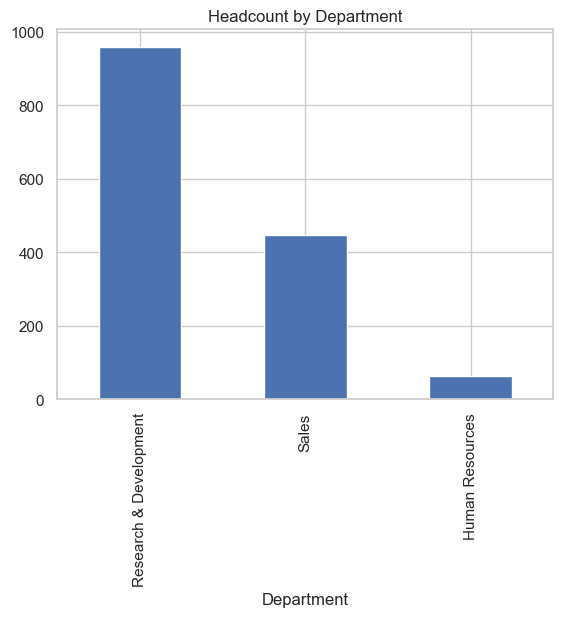

In [65]:
df["Department"].value_counts().plot(kind="bar")
plt.title("Headcount by Department")
plt.show()

Job Level Distribution

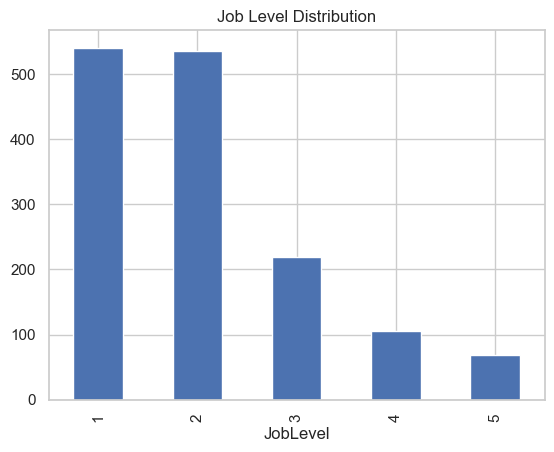

In [66]:
df["JobLevel"].value_counts().sort_index().plot(kind="bar")
plt.title("Job Level Distribution")
plt.show()

Age Distribution

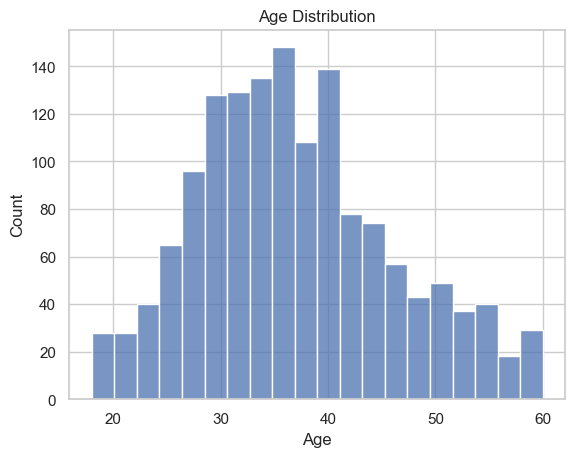

In [67]:
sns.histplot(df["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

Workforce Composition

* The organization is heavily concentrated in R&D, followed by Sales, with HR being the smallest department.

* Majority of employees are in Job Levels 1 and 2, indicating a junior-heavy workforce structure.

* Workforce age distribution is centered between 30–40 years, with a range from 18 to 60.

##### ATTRITION SEGMENTATION

Attrition by Department

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_99302/2348391995.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dept_attrition = df.groupby("Department")["Attrition"].mean()


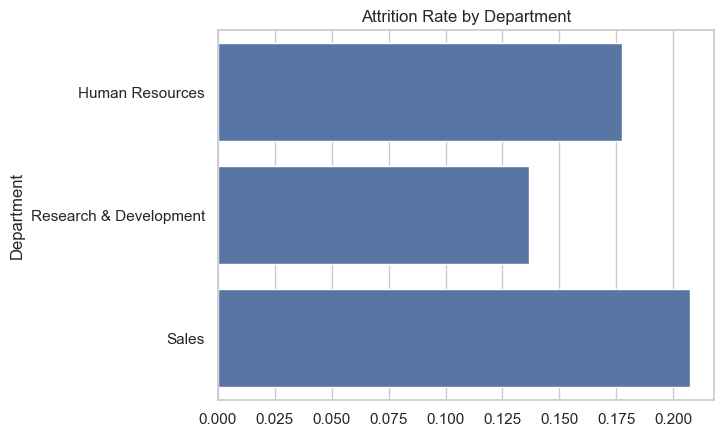

In [68]:
dept_attrition = df.groupby("Department")["Attrition"].mean()

sns.barplot(x=dept_attrition.values, y=dept_attrition.index)
plt.title("Attrition Rate by Department")
plt.show()

Attrition by Job Level

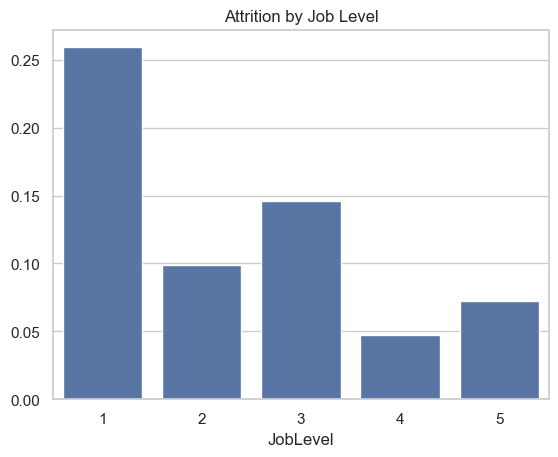

In [69]:
joblevel_attrition = df.groupby("JobLevel")["Attrition"].mean()

sns.barplot(x=joblevel_attrition.index, y=joblevel_attrition.values)
plt.title("Attrition by Job Level")
plt.show()

Attrition Concentration

* Overall attrition is approximately ~16%.

* Attrition is highest in the Sales department, followed by HR, and lowest in R&D.

* Job Level 1 employees show the highest attrition rate (~25%), indicating early-career churn.

* Higher job levels show elevated percentages but are based on significantly smaller populations.

Attrition vs Tenure

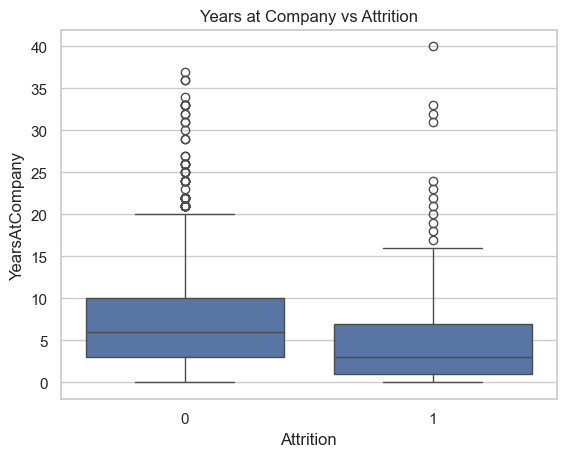

In [70]:
sns.boxplot(x="Attrition", y="YearsAtCompany", data=df)
plt.title("Years at Company vs Attrition")
plt.show()

Tenure Impact

* Employees who leave have significantly shorter tenure:

    * Leavers: Median tenure ≈ 3 years

    * Stayers: Median tenure ≈ 6 years

* Attrition is concentrated in employees within their first few years at the company, suggesting early disengagement.

Distance + Attrition

In [71]:
df.groupby("Attrition")["DistanceFromHome"].mean()

Attrition
0     8.910859
1    10.646809
Name: DistanceFromHome, dtype: float64

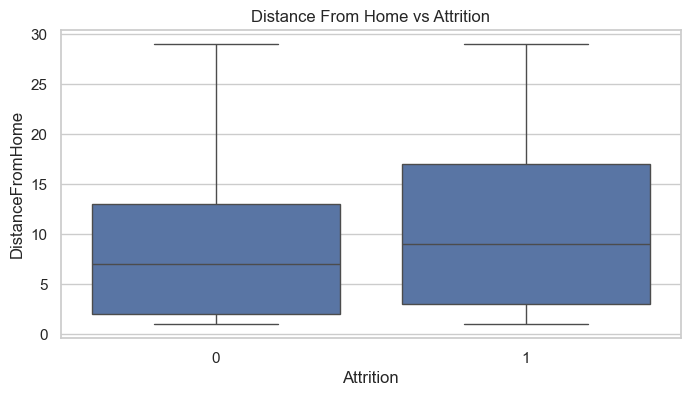

In [72]:
plt.figure(figsize=(8,4))
sns.boxplot(x="Attrition", y="DistanceFromHome", data=df)
plt.title("Distance From Home vs Attrition")
plt.show()

Distance From Home

* Average distance for leavers: 10.6

* Average distance for stayers: 8.9

Interpretation:
Employees who leave live slightly farther from the workplace, but the difference is modest. Commute distance may contribute marginally to attrition but does not appear to be a primary driver.

In [73]:
df["DistanceBucket"] = pd.cut(
    df["DistanceFromHome"],
    bins=[0,5,10,20,30],
    labels=["0-5","6-10","11-20","21-30"]
)

df.groupby("DistanceBucket")["Attrition"].mean()

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_99302/437966476.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("DistanceBucket")["Attrition"].mean()


DistanceBucket
0-5      0.134707
6-10     0.144670
11-20    0.203320
21-30    0.216749
Name: Attrition, dtype: float64

Gender

In [74]:
df.groupby("Gender")["Attrition"].mean()

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_99302/1933262186.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Gender")["Attrition"].mean()


Gender
Female    0.146259
Male      0.169126
Name: Attrition, dtype: float64

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_99302/723838857.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x=df.groupby("Gender")["Attrition"].mean().index,
/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_99302/723838857.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y=df.groupby("Gender")["Attrition"].mean().values


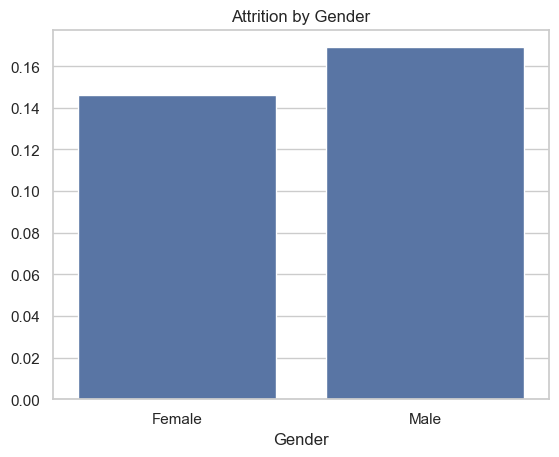

In [75]:
sns.barplot(
    x=df.groupby("Gender")["Attrition"].mean().index,
    y=df.groupby("Gender")["Attrition"].mean().values
)
plt.title("Attrition by Gender")
plt.show()

Gender

* Female attrition: 14.6%

* Male attrition: 16.9%

Interpretation:
Attrition rates are relatively similar across genders. There is no strong evidence of gender-based turnover imbalance.

Marital Status

In [76]:
df.groupby("MaritalStatus")["Attrition"].mean()

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_99302/133214656.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("MaritalStatus")["Attrition"].mean()


MaritalStatus
Divorced    0.100917
Married     0.123328
Single      0.253731
Name: Attrition, dtype: float64

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_99302/193069448.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x=df.groupby("MaritalStatus")["Attrition"].mean().index,
/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_99302/193069448.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y=df.groupby("MaritalStatus")["Attrition"].mean().values


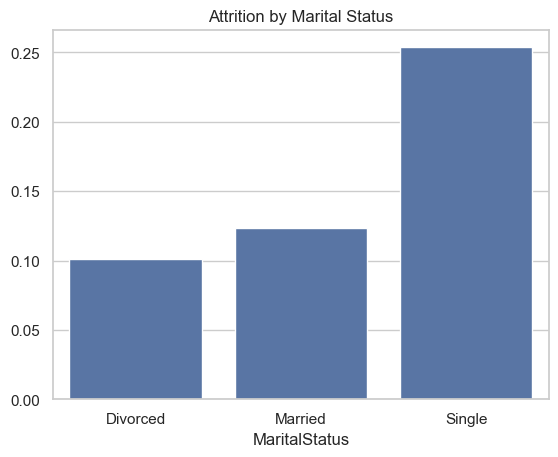

In [77]:
sns.barplot(
    x=df.groupby("MaritalStatus")["Attrition"].mean().index,
    y=df.groupby("MaritalStatus")["Attrition"].mean().values
)
plt.title("Attrition by Marital Status")
plt.show()

Marital Status

* Divorced: 10%

* Married: 12%

* Single: 25%

Interpretation:
Single employees exhibit significantly higher attrition (~25%). This likely reflects higher mobility among early-career professionals and aligns with the earlier finding of junior-level attrition concentration.

Business Travel

In [78]:
df.groupby("BusinessTravel")["Attrition"].mean()

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_99302/4146843279.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("BusinessTravel")["Attrition"].mean()


BusinessTravel
Non-Travel           0.080000
Travel_Frequently    0.240876
Travel_Rarely        0.150239
Name: Attrition, dtype: float64

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_99302/1581970430.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x=df.groupby("BusinessTravel")["Attrition"].mean().index,
/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_99302/1581970430.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  y=df.groupby("BusinessTravel")["Attrition"].mean().values


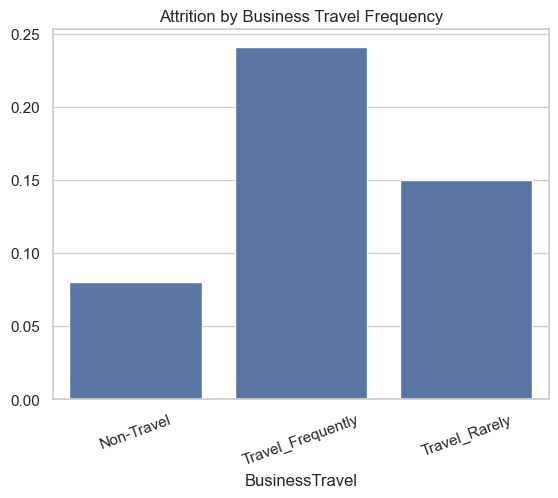

In [79]:
sns.barplot(
    x=df.groupby("BusinessTravel")["Attrition"].mean().index,
    y=df.groupby("BusinessTravel")["Attrition"].mean().values
)
plt.title("Attrition by Business Travel Frequency")
plt.xticks(rotation=20)
plt.show()

Business Travel

* Non-travel: 8%

* Travel rarely: 15%

* Travel frequently: 24%

Interpretation:
Frequent business travel is strongly associated with higher attrition. Employees traveling frequently are nearly 3x more likely to leave than non-travel employees, indicating potential burnout or work-life imbalance.

Percent Salary Hike

In [80]:
df.groupby("Attrition")["PercentSalaryHike"].mean()

Attrition
0    15.234198
1    15.093617
Name: PercentSalaryHike, dtype: float64

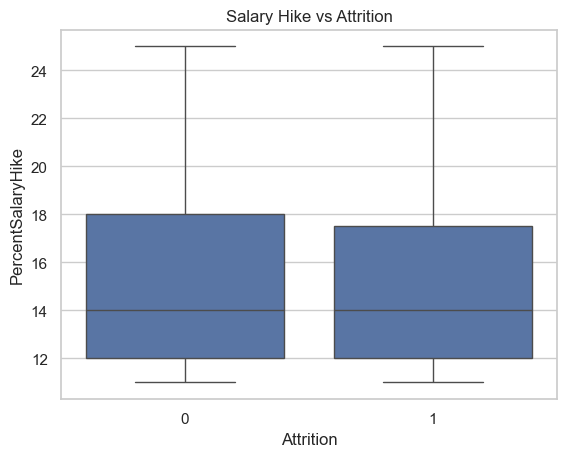

In [81]:
sns.boxplot(x="Attrition", y="PercentSalaryHike", data=df)
plt.title("Salary Hike vs Attrition")
plt.show()

Percent Salary Hike

* Stayers: 15.23%

* Leavers: 15.09%

Interpretation:
There is virtually no difference in annual salary hike between stayers and leavers. This suggests that standard yearly increments alone are unlikely to significantly influence retention.

Years Since Last Promotion

In [82]:
df.groupby("Attrition")["YearsSinceLastPromotion"].mean()

Attrition
0    2.235008
1    1.965957
Name: YearsSinceLastPromotion, dtype: float64

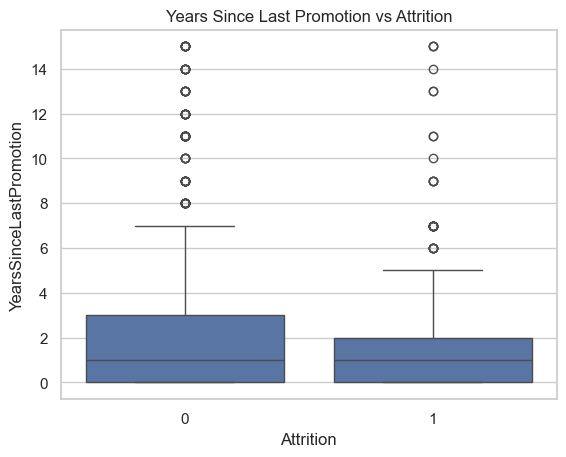

In [83]:
sns.boxplot(x="Attrition", y="YearsSinceLastPromotion", data=df)
plt.title("Years Since Last Promotion vs Attrition")
plt.show()

Years Since Last Promotion

* Stayers: 2.23 years

* Leavers: 1.96 years

Interpretation:
Leavers have slightly fewer years since last promotion. Promotion delay does not appear to be a major structural driver in this dataset.

Education

In [84]:
df.groupby("Education")["Attrition"].mean()

Education
1    0.177515
2    0.156028
3    0.171329
4    0.145729
5    0.104167
Name: Attrition, dtype: float64

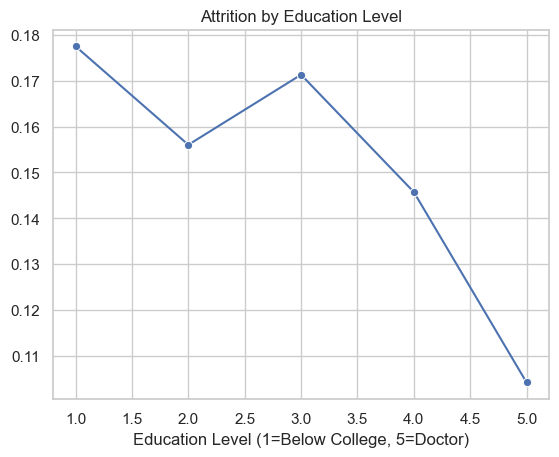

In [85]:
sns.lineplot(
    x=df.groupby("Education")["Attrition"].mean().index,
    y=df.groupby("Education")["Attrition"].mean().values,
    marker="o"
)
plt.title("Attrition by Education Level")
plt.xlabel("Education Level (1=Below College, 5=Doctor)") 
plt.show()

Education Level

Attrition by education:

* Level 1: 17.7%

* Level 2: 15.6%

* Level 3: 17.1%

* Level 4: 14.5%

* Level 5: 10.4%

Interpretation:
No strong monotonic pattern exists between education level and attrition. Education does not appear to be a primary driver of turnover.

Years with Current Manager

In [86]:
df.groupby("Attrition")["YearsWithCurrManager"].mean()

Attrition
0    4.367099
1    2.863830
Name: YearsWithCurrManager, dtype: float64

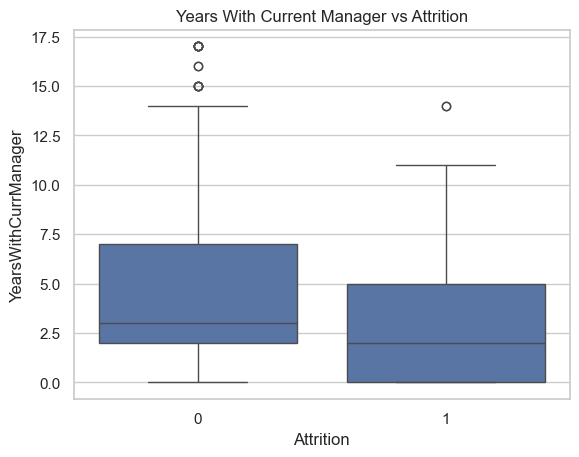

In [87]:
sns.boxplot(x="Attrition", y="YearsWithCurrManager", data=df)
plt.title("Years With Current Manager vs Attrition")
plt.show()

Years With Current Manager

* Stayers: 4.37 years

* Leavers: 2.86 years

Interpretation:
Employees who leave tend to have spent less time with their current manager. This may indicate early dissatisfaction with managerial relationships or lack of managerial stability.

Overtime Impact

/var/folders/bc/5y5fg3_57cx7hhmrks5902vw0000gp/T/ipykernel_99302/3265573934.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  overtime_attrition = df.groupby("OverTime")["Attrition"].mean()


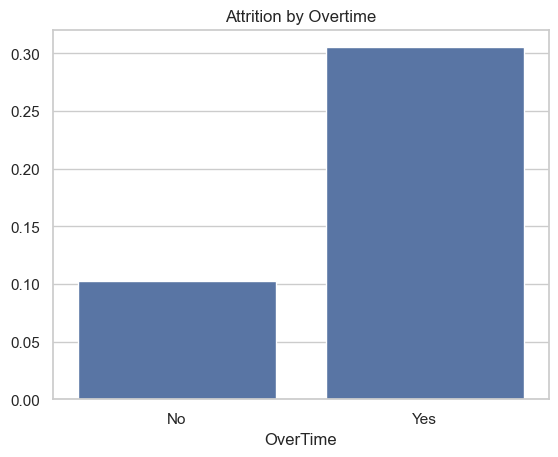

In [88]:
overtime_attrition = df.groupby("OverTime")["Attrition"].mean()

sns.barplot(x=overtime_attrition.index, y=overtime_attrition.values)
plt.title("Attrition by Overtime")
plt.show()

Overtime as a Strong Risk Indicator

* Employees working overtime have ~30% attrition, compared to ~10% for those not working overtime.

* Overtime appears to be one of the strongest observable drivers of turnover.

##### ORDINAL VARIABLES ANALYSIS

Job Satisfaction Trend

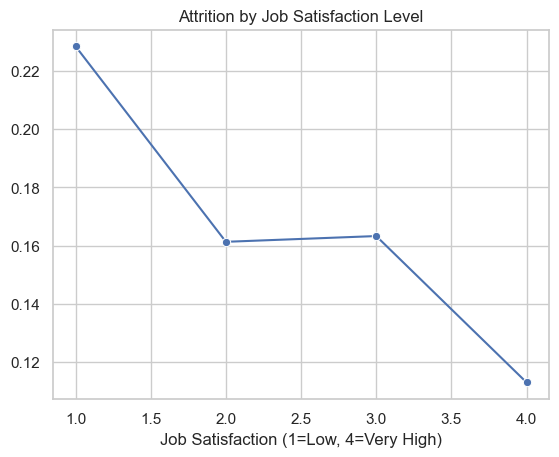

Attrition
0    4.367099
1    2.863830
Name: YearsWithCurrManager, dtype: float64

In [89]:
js_attrition = df.groupby("JobSatisfaction")["Attrition"].mean()

sns.lineplot(x=js_attrition.index, y=js_attrition.values, marker="o")
plt.title("Attrition by Job Satisfaction Level")
plt.xlabel("Job Satisfaction (1=Low, 4=Very High)")
plt.show()

df.groupby("Attrition")["YearsWithCurrManager"].mean()

Work Life Balance Trend

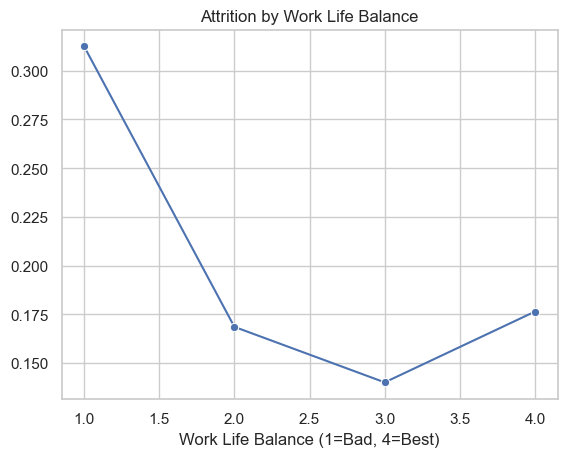

WorkLifeBalance
1    0.312500
2    0.168605
3    0.140135
4    0.176471
Name: Attrition, dtype: float64

In [90]:
wlb_attrition = df.groupby("WorkLifeBalance")["Attrition"].mean()

sns.lineplot(x=wlb_attrition.index, y=wlb_attrition.values, marker="o")
plt.title("Attrition by Work Life Balance")
plt.xlabel("Work Life Balance (1=Bad, 4=Best)")
plt.show()

df.groupby("WorkLifeBalance")["Attrition"].mean()

Work-Life Balance

* Bad: 31%

* Good: 16.8%

* Better: 14%

* Best: 17.6%

Interpretation:
Poor work-life balance is strongly associated with attrition. Employees reporting bad balance have more than double the attrition risk compared to those reporting better balance.

Environment Satisfaction

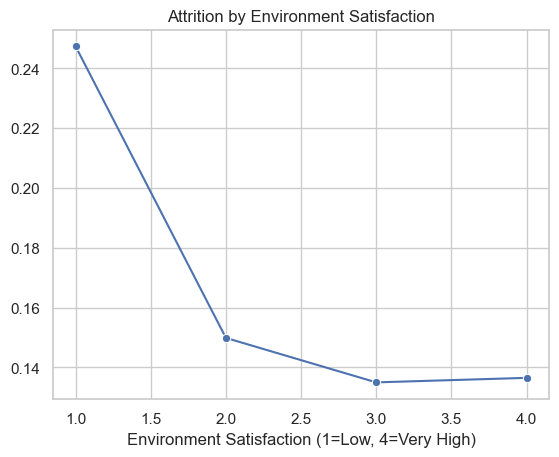

EnvironmentSatisfaction
1    0.247350
2    0.149826
3    0.134956
4    0.136465
Name: Attrition, dtype: float64

In [91]:
env_attrition = df.groupby("EnvironmentSatisfaction")["Attrition"].mean()

sns.lineplot(x=env_attrition.index, y=env_attrition.values, marker="o")
plt.title("Attrition by Environment Satisfaction")
plt.xlabel("Environment Satisfaction (1=Low, 4=Very High)")
plt.show()

df.groupby("EnvironmentSatisfaction")["Attrition"].mean()

Environment Satisfaction

* Low: 24.7%

* Medium: 14.9%

* High: 13.4%

* Very High: 13.6%

Interpretation:
Lower environment satisfaction is clearly linked to higher attrition. Engagement and workplace environment appear to play a significant role in retention.

Satisfaction & Engagement Drivers

Attrition consistently increases as satisfaction decreases:

* Low Job Satisfaction → ~23% attrition

* Low Environment Satisfaction → ~25% attrition

* Poor Work-Life Balance → 30%+ attrition

This indicates a clear relationship between engagement metrics and turnover risk.

##### Compensation Analysis

Monthly Income vs Attrition

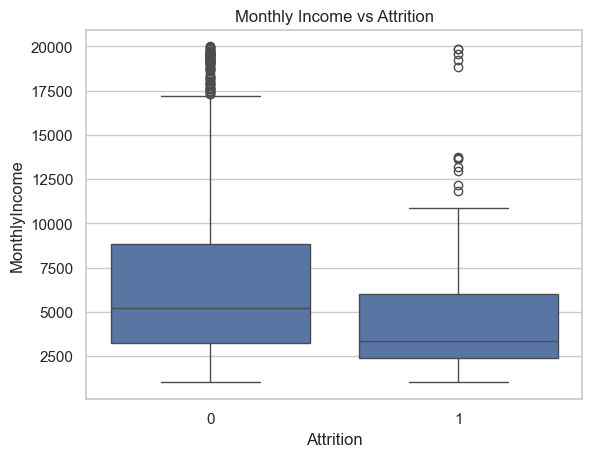

Attrition
0    6833.397083
1    4830.663830
Name: MonthlyIncome, dtype: float64

In [92]:
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

df.groupby("Attrition")["MonthlyIncome"].mean()

Monthly Income

* Stayers average: 6,833

* Leavers average: 4,830

Interpretation:
Employees who leave earn significantly less on average. However, this is likely intertwined with job level and tenure effects rather than pure compensation dissatisfaction.

Summary Table

In [93]:
summary = df.groupby("Attrition").agg({
    "Age": "mean",
    "MonthlyIncome": "mean",
    "YearsAtCompany": "mean",
    "JobSatisfaction": "mean",
    "WorkLifeBalance": "mean",
    "DistanceFromHome": "mean",
})

summary

,Age,MonthlyIncome,YearsAtCompany,JobSatisfaction,WorkLifeBalance,DistanceFromHome
Attrition,,,,,,
0,37.559968,6833.397083,7.370340,2.779579,2.781199,8.910859
1,33.668085,4830.663830,5.153191,2.468085,2.655319,10.646809


Attrition risk is highest among:

* Single employees

* Early-career (Job Level 1) professionals

* Employees working frequent overtime

* Employees traveling frequently

* Those reporting low satisfaction and poor work-life balance

* Lower-income employees

The strongest observable drivers from EDA appear to be:

Overtime, business travel frequency, work-life balance, environment satisfaction, and early-career status.